# Otimização do Limiar de Decisão

Determina o limiar (_threshold_) de decisão ótimo para cada configuração finalista, substituindo o valor padrão de `0.5` por um valor calculado a partir das predições brutas do modelo.

**Método:** índice de Youden — maximiza a soma de sensibilidade e especificidade ao longo da curva ROC:

$$J = \max(TPR - FPR)$$

O threshold ótimo é calculado de forma agregada sobre as predições das 3 runs independentes, concatenando os arquivos `predictions.csv` de cada run antes de aplicar o índice de Youden. Isso produz um threshold mais estável do que a média de três valores individuais.

**Configurações avaliadas:**

| Identificador | Configuração |
|---|---|
| `*-best-auc-1e-3` | maior AUC-ROC, learning rate `0.001` |
| `*-best-cm-1e-3` | melhor equilíbrio recall/especificidade, learning rate `0.001` |

> **Nota clínica:** o índice de Youden pondera igualmente sensibilidade e especificidade. Em aplicações de triagem de pneumonia, dependendo do contexto clínico, pode ser preferível priorizar a sensibilidade (minimizar falsos negativos) em detrimento da especificidade.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão salvas no Google Drive

In [3]:
experiment_names = ["resnet-final-1", "resnet-final-2",
                  "densenet-final-1", "densenet-final-2",
                  "efficientnet-final-1", "efficientnet-final-2"]

COMPARISON_PATH = "comparisons/06-optimal-threshold"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [5]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-final-1,0.905449,0.002266,0.945295,0.002470,0.900855,0.001209,0.922539,0.001810,0.913105,0.004029,0.963566,0.003803
resnet-final-2,0.881944,0.026731,0.942576,0.014804,0.864957,0.059228,0.900517,0.026745,0.910256,0.029813,0.956834,0.003682
densenet-final-1,0.880876,0.044764,0.935291,0.037997,0.875214,0.103676,0.898807,0.045765,0.890313,0.075994,0.962950,0.003478
densenet-final-2,0.897436,0.002617,0.930336,0.017147,0.904274,0.016792,0.916808,0.001657,0.886040,0.032421,0.956323,0.000575
efficientnet-final-1,0.911325,0.006044,0.947609,0.007872,0.908547,0.016922,0.927508,0.005720,0.915954,0.014527,0.969923,0.001793
efficientnet-final-2,0.877671,0.037225,0.935217,0.025885,0.867521,0.087689,0.896328,0.038648,0.894587,0.049878,0.961739,0.000533


## Visualização da matriz de confusão dos experimentos com ResNet

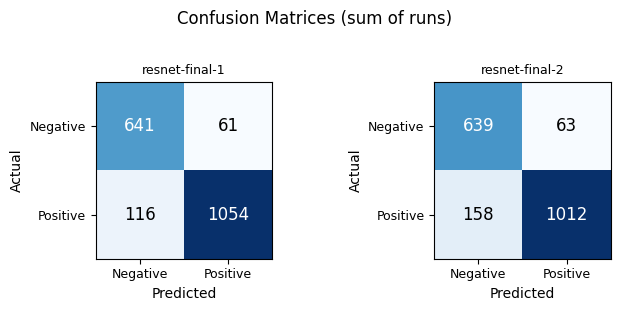

In [6]:
from src.analyses import plot_confusion_matrices
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig = plot_confusion_matrices(resnet_exps)

plt.show()

## Visualização da matriz de confusão dos experimentos com DenseNet

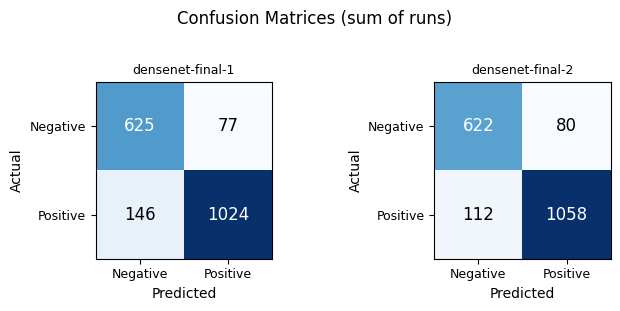

In [7]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_confusion_matrices(densenet_exps)

plt.show()

## Visualização da matriz de confusão dos experimentos com EfficientNet

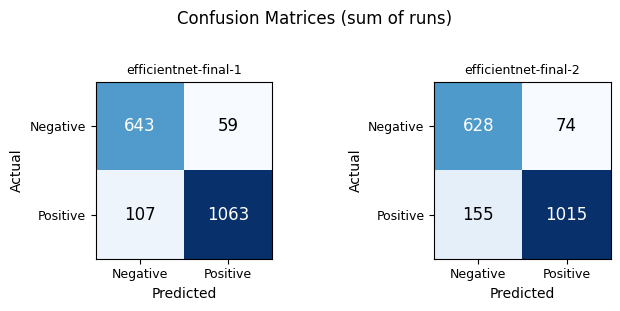

In [8]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_confusion_matrices(efficientnet_exps)

plt.show()

## Salvamento da comparação completa

A comparação completa é salva no Google Drive

In [9]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/06-optimal-threshold


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)